In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [172]:
data_path = Path("D:/clv/data/processed/customer_segments.csv")

customer_data = pd.read_csv(data_path)

print("Dataset shape:", customer_data.shape)

Dataset shape: (5881, 27)


In [173]:
print(customer_data.columns.tolist())

['customer_id', 'total_orders', 'total_items', 'total_revenue', 'first_purchase', 'last_purchase', 'recency', 'frequency', 'monetary', 'avg_order_value', 'avg_items_per_order', 'unique_products', 'active_months', 'customer_lifetime_days', 'avg_purchase_interval_days', 'weekend_purchase_ratio', 'return_orders', 'returned_items', 'return_order_rate', 'return_item_rate', 'R_score', 'F_score', 'M_score', 'RFM_score', 'rfm_segment', 'cluster', 'customer_segment']


In [174]:
customer_data.head()

,customer_id,total_orders,total_items,total_revenue,first_purchase,last_purchase,recency,frequency,monetary,avg_order_value,avg_items_per_order,unique_products,active_months,customer_lifetime_days,avg_purchase_interval_days,weekend_purchase_ratio,return_orders,returned_items,return_order_rate,return_item_rate,R_score,F_score,M_score,RFM_score,rfm_segment,cluster,customer_segment
0,"12,346.00",12,74285,"77,556.46",2009-12-14 08:34:00,2011-01-18 10:01:00,326,12,"77,556.46","6,463.04","6,190.42",27,5,400,11.97,0.00,5.00,"74,232.00",0.42,0.50,2,5,5,255,At Risk,2,High-Value Occasional Buyers
1,"12,347.00",8,2967,"4,921.53",2010-10-31 14:20:00,2011-12-07 15:52:00,2,8,"4,921.53",615.19,370.88,126,8,402,1.81,0.18,0.00,0.00,0.00,0.00,5,4,5,545,Champions,4,Champions
2,"12,348.00",5,2714,"2,019.40",2010-09-27 14:59:00,2011-09-25 13:13:00,75,5,"2,019.40",403.88,542.80,25,5,362,7.24,0.06,0.00,0.00,0.00,0.00,3,4,4,344,Loyal Customers,2,High-Value Occasional Buyers
3,"12,349.00",4,1624,"4,428.69",2010-04-29 13:20:00,2011-11-21 09:51:00,19,4,"4,428.69","1,107.17",406.00,138,4,570,3.27,0.00,1.00,5.00,0.25,0.00,5,3,5,535,Potential Loyalists,2,High-Value Occasional Buyers
4,"12,350.00",1,197,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00,310,1,334.40,334.40,197.00,17,1,0,0.00,0.00,0.00,0.00,0.00,0.00,2,1,2,212,Lost,0,Dormant Customers


In [175]:
print("Number of rows:", len(customer_data))
print(
    "Unique customers:",
    customer_data["customer_id"].nunique()
)
print(
    "Duplicate customer IDs:",
    customer_data["customer_id"].duplicated().sum()
)
print(
    "Missing values:",
    customer_data.isna().sum().sum()
)

Number of rows: 5881
Unique customers: 5881
Duplicate customer IDs: 0
Missing values: 118


In [176]:
segment_distribution = (
    customer_data["customer_segment"]
    .value_counts()
    .to_frame("customers")
)

segment_distribution["customer_share_pct"] = (
    segment_distribution["customers"]
    / len(customer_data)
    * 100
).round(2)

segment_distribution

,customers,customer_share_pct
customer_segment,,
Regular Growth Customers,1726,29.35
Dormant Customers,1411,23.99
Champions,1178,20.03
High-Value Occasional Buyers,945,16.07
Lost Low-Value Customers,621,10.56


In [177]:
segment_order = [
    "Champions",
    "High-Value Occasional Buyers",
    "Regular Growth Customers",
    "Dormant Customers",
    "Lost Low-Value Customers"
]
customer_data["customer_segment"] = pd.Categorical(
    customer_data["customer_segment"],
    categories=segment_order,
    ordered=True
)

In [178]:
profile_features = [
    "recency",
    "frequency",
    "monetary",
    "avg_order_value",
    "avg_items_per_order",
    "unique_products",
    "active_months",
    "customer_lifetime_days",
    "return_order_rate",
    "return_item_rate"
]
segment_profile = (
    customer_data
    .groupby(
        "customer_segment",
        observed=True
    )[profile_features]
    .median()
    .round(2)
)

segment_profile

,recency,frequency,monetary,avg_order_value,avg_items_per_order,unique_products,active_months,customer_lifetime_days,return_order_rate,return_item_rate
customer_segment,,,,,,,,,,
Champions,23.00,13.00,"4,976.60",393.61,231.90,172.00,10.00,625.00,0.20,0.01
High-Value Occasional Buyers,130.00,2.00,"1,345.21",561.88,360.75,54.00,2.00,121.00,0.00,0.00
Regular Growth Customers,57.00,4.00,"1,004.13",226.69,121.60,56.00,4.00,374.00,0.00,0.00
Dormant Customers,388.00,1.00,306.94,228.96,132.00,19.00,1.00,0.00,0.00,0.00
Lost Low-Value Customers,389.00,1.00,121.74,95.93,36.50,6.00,1.00,0.00,0.00,0.00


In [179]:
profile_features = [
    "recency",
    "frequency",
    "monetary",
    "avg_order_value",
    "avg_items_per_order",
    "unique_products",
    "active_months",
    "customer_lifetime_days",
    "return_order_rate",
    "return_item_rate"
]

# Median behavioral profile by segment
segment_profile = (
    customer_data
    .groupby(
        "customer_segment",
        observed=True
    )[profile_features]
    .median()
    .round(2)
)

# Customer count
segment_profile["customers"] = (
    customer_data
    .groupby(
        "customer_segment",
        observed=True
    )["customer_id"]
    .nunique()
)

# Customer share
segment_profile["customer_share_pct"] = (
    segment_profile["customers"]
    / segment_profile["customers"].sum()
    * 100
).round(2)

# Reorder columns
segment_profile = segment_profile[
    [
        "customers",
        "customer_share_pct",
        "recency",
        "frequency",
        "monetary",
        "avg_order_value",
        "avg_items_per_order",
        "unique_products",
        "active_months",
        "customer_lifetime_days",
        "return_order_rate",
        "return_item_rate"
    ]
]

segment_profile

,customers,customer_share_pct,recency,frequency,monetary,avg_order_value,avg_items_per_order,unique_products,active_months,customer_lifetime_days,return_order_rate,return_item_rate
customer_segment,,,,,,,,,,,,
Champions,1178,20.03,23.00,13.00,"4,976.60",393.61,231.90,172.00,10.00,625.00,0.20,0.01
High-Value Occasional Buyers,945,16.07,130.00,2.00,"1,345.21",561.88,360.75,54.00,2.00,121.00,0.00,0.00
Regular Growth Customers,1726,29.35,57.00,4.00,"1,004.13",226.69,121.60,56.00,4.00,374.00,0.00,0.00
Dormant Customers,1411,23.99,388.00,1.00,306.94,228.96,132.00,19.00,1.00,0.00,0.00,0.00
Lost Low-Value Customers,621,10.56,389.00,1.00,121.74,95.93,36.50,6.00,1.00,0.00,0.00,0.00


In [180]:
segment_revenue = (
    customer_data
    .groupby(
        "customer_segment",
        observed=True
    )
    .agg(
        customers=("customer_id", "nunique"),
        total_revenue=("monetary", "sum"),
        avg_customer_revenue=("monetary", "mean"),
        median_customer_revenue=("monetary", "median")
    )
)

segment_revenue["customer_share_pct"] = (
    segment_revenue["customers"]
    / segment_revenue["customers"].sum()
    * 100
).round(2)

segment_revenue["revenue_share_pct"] = (
    segment_revenue["total_revenue"]
    / segment_revenue["total_revenue"].sum()
    * 100
).round(2)

segment_revenue = (
    segment_revenue
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

segment_revenue

,customers,total_revenue,avg_customer_revenue,median_customer_revenue,customer_share_pct,revenue_share_pct
customer_segment,,,,,,
Champions,1178,"12,493,975.04","10,606.09","4,976.60",20.03,71.91
High-Value Occasional Buyers,945,"2,289,819.68","2,423.09","1,345.21",16.07,13.18
Regular Growth Customers,1726,"1,981,781.03","1,148.19","1,004.13",29.35,11.41
Dormant Customers,1411,"494,198.73",350.25,306.94,23.99,2.84
Lost Low-Value Customers,621,"115,029.78",185.23,121.74,10.56,0.66


In [181]:
total_revenue = customer_data["monetary"].sum()

top_20_count = int(
    len(customer_data) * 0.20
)

top_20_revenue = (
    customer_data["monetary"]
    .sort_values(ascending=False)
    .head(top_20_count)
    .sum()
)

top_20_revenue_share = (
    top_20_revenue
    / total_revenue
    * 100
)

print(
    f"Top 20% of customers generate "
    f"{top_20_revenue_share:.2f}% of total revenue."
)

Top 20% of customers generate 77.25% of total revenue.


In [182]:
overall_median = (
    customer_data[profile_features]
    .median()
)

segment_index = (
    segment_profile[profile_features]
    / overall_median
).round(2)

segment_index

,recency,frequency,monetary,avg_order_value,avg_items_per_order,unique_products,active_months,customer_lifetime_days,return_order_rate,return_item_rate
customer_segment,,,,,,,,,,
Champions,0.24,4.33,5.75,1.41,1.51,3.82,3.33,2.84,inf,inf
High-Value Occasional Buyers,1.35,0.67,1.55,2.01,2.35,1.20,0.67,0.55,NaN,NaN
Regular Growth Customers,0.59,1.33,1.16,0.81,0.79,1.24,1.33,1.70,NaN,NaN
Dormant Customers,4.04,0.33,0.35,0.82,0.86,0.42,0.33,0.00,NaN,NaN
Lost Low-Value Customers,4.05,0.33,0.14,0.34,0.24,0.13,0.33,0.00,NaN,NaN


In [183]:
rfm_distribution = pd.crosstab(
    customer_data["customer_segment"],
    customer_data["rfm_segment"],
    normalize="index"
).round(3)

rfm_distribution

rfm_segment,At Risk,Champions,Lost,Loyal Customers,Potential Loyalists,Regular Customers
customer_segment,,,,,,
Champions,0.05,0.77,0.00,0.18,0.00,0.00
High-Value Occasional Buyers,0.19,0.07,0.24,0.06,0.24,0.20
Regular Growth Customers,0.19,0.19,0.02,0.24,0.23,0.14
Dormant Customers,0.03,0.00,0.64,0.00,0.13,0.20
Lost Low-Value Customers,0.01,0.00,0.59,0.03,0.14,0.23


In [184]:
dominant_rfm = (
    rfm_distribution
    .idxmax(axis=1)
    .rename("dominant_rfm_segment")
)

dominant_rfm

customer_segment
Champions                             Champions
High-Value Occasional Buyers               Lost
Regular Growth Customers        Loyal Customers
Dormant Customers                          Lost
Lost Low-Value Customers                   Lost
Name: dominant_rfm_segment, dtype: str

In [185]:
return_analysis = (
    customer_data
    .groupby(
        "customer_segment",
        observed=True
    )
    .agg(
        customers=("customer_id", "nunique"),

        avg_return_order_rate=(
            "return_order_rate",
            "mean"
        ),

        median_return_order_rate=(
            "return_order_rate",
            "median"
        ),

        avg_return_item_rate=(
            "return_item_rate",
            "mean"
        ),

        median_return_item_rate=(
            "return_item_rate",
            "median"
        ),

        customers_with_returns=(
            "return_order_rate",
            lambda x: (x > 0).sum()
        )
    )
)
return_analysis["returning_customer_pct"] = (
    return_analysis["customers_with_returns"]
    / return_analysis["customers"]
    * 100
).round(2)

return_analysis

,customers,avg_return_order_rate,median_return_order_rate,avg_return_item_rate,median_return_item_rate,customers_with_returns,returning_customer_pct
customer_segment,,,,,,,
Champions,1178,0.25,0.20,0.02,0.01,1043,88.54
High-Value Occasional Buyers,945,0.27,0.00,0.02,0.00,366,38.73
Regular Growth Customers,1726,0.18,0.00,0.01,0.00,793,45.94
Dormant Customers,1411,0.14,0.00,0.01,0.00,219,15.52
Lost Low-Value Customers,621,0.13,0.00,0.03,0.00,90,14.49


In [186]:
engagement_analysis = (
    customer_data
    .groupby(
        "customer_segment",
        observed=True
    )
    .agg(
        median_recency=("recency", "median"),
        median_frequency=("frequency", "median"),
        median_active_months=("active_months", "median"),
        median_lifetime_days=(
            "customer_lifetime_days",
            "median"
        )
    )
    .round(2)
)

engagement_analysis

,median_recency,median_frequency,median_active_months,median_lifetime_days
customer_segment,,,,
Champions,23.00,13.00,10.00,625.00
High-Value Occasional Buyers,130.00,2.00,2.00,121.00
Regular Growth Customers,57.00,4.00,4.00,374.00
Dormant Customers,388.00,1.00,1.00,0.00
Lost Low-Value Customers,389.00,1.00,1.00,0.00


In [187]:
high_value_threshold = (
    customer_data["monetary"]
    .quantile(0.75)
)

dormant_threshold = (
    customer_data["recency"]
    .quantile(0.75)
)

print(
    "High-value threshold:",
    round(high_value_threshold, 2)
)

print(
    "Dormant threshold:",
    round(dormant_threshold, 2)
)

high_value_dormant = customer_data[
    (customer_data["monetary"] >= high_value_threshold)
    &
    (customer_data["recency"] >= dormant_threshold)
].copy()

print(
    "High-value dormant customers:",
    len(high_value_dormant)
)

High-value threshold: 2247.72
Dormant threshold: 380.0
High-value dormant customers: 65


In [188]:
high_value_dormant_summary = (
    high_value_dormant
    .groupby(
        "customer_segment",
        observed=True
    )
    .agg(
        customers=("customer_id", "nunique"),
        total_revenue=("monetary", "sum"),
        median_revenue=("monetary", "median"),
        median_recency=("recency", "median"),
        median_frequency=("frequency", "median")
    )
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

high_value_dormant_summary

,customers,total_revenue,median_revenue,median_recency,median_frequency
customer_segment,,,,,
High-Value Occasional Buyers,40,"220,616.09","3,280.98",505.50,3.00
Champions,16,"109,506.05","4,622.94",429.00,11.50
Dormant Customers,2,"24,869.84","12,434.92",628.50,1.50
Regular Growth Customers,5,"13,120.41","2,729.84",429.00,12.00
Lost Low-Value Customers,2,"9,711.99","4,855.99",459.50,2.50


In [189]:
frequency_threshold = (
    customer_data["frequency"]
    .median()
)

active_recency_threshold = (
    customer_data["recency"]
    .median()
)

growth_candidates = customer_data[
    (customer_data["frequency"] >= frequency_threshold)
    &
    (customer_data["recency"] <= active_recency_threshold)
    &
    (customer_data["monetary"] < high_value_threshold)
].copy()
print(
    "Growth opportunity customers:",
    len(growth_candidates)
)

Growth opportunity customers: 1044


In [190]:
growth_summary = (
    growth_candidates
    .groupby(
        "customer_segment",
        observed=True
    )
    .agg(
        customers=("customer_id", "nunique"),
        total_revenue=("monetary", "sum"),
        median_frequency=("frequency", "median"),
        median_recency=("recency", "median"),
        median_monetary=("monetary", "median")
    )
    .sort_values(
        "customers",
        ascending=False
    )
)

growth_summary

,customers,total_revenue,median_frequency,median_recency,median_monetary
customer_segment,,,,,
Regular Growth Customers,849,"981,940.54",5.00,25.00,"1,082.81"
High-Value Occasional Buyers,111,"174,024.28",3.00,40.00,"1,481.40"
Champions,43,"86,813.86",6.00,41.00,"2,041.80"
Lost Low-Value Customers,39,"13,737.00",3.00,29.00,271.40
Dormant Customers,2,"1,019.00",3.50,53.00,509.50


In [191]:
median_recency = (
    customer_data["recency"].median()
)

median_monetary = (
    customer_data["monetary"].median()
)

customer_data["value_status"] = np.select(
    [
        (
            (customer_data["monetary"] >= median_monetary)
            &
            (customer_data["recency"] <= median_recency)
        ),

        (
            (customer_data["monetary"] >= median_monetary)
            &
            (customer_data["recency"] > median_recency)
        ),

        (
            (customer_data["monetary"] < median_monetary)
            &
            (customer_data["recency"] <= median_recency)
        )
    ],
    [
        "High Value - Active",
        "High Value - Dormant",
        "Lower Value - Active"
    ],
    default="Lower Value - Dormant"
)

customer_data["value_status"].value_counts()

value_status
High Value - Active      2027
Lower Value - Dormant    2013
Lower Value - Active      927
High Value - Dormant      914
Name: count, dtype: int64

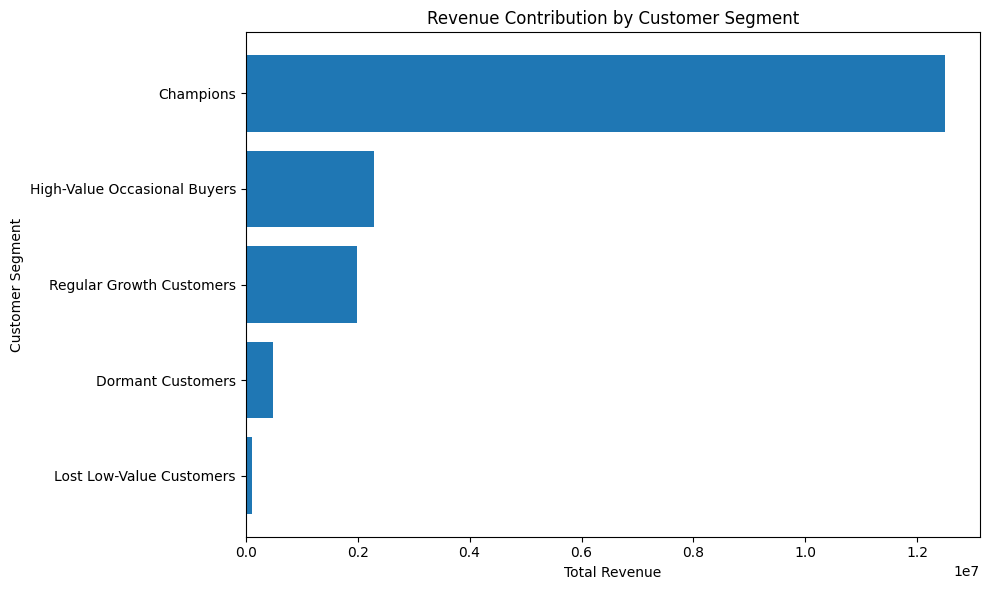

In [192]:
plot_data = (
    segment_revenue
    .sort_values("total_revenue")
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data.index,
    plot_data["total_revenue"]
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Total Revenue")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

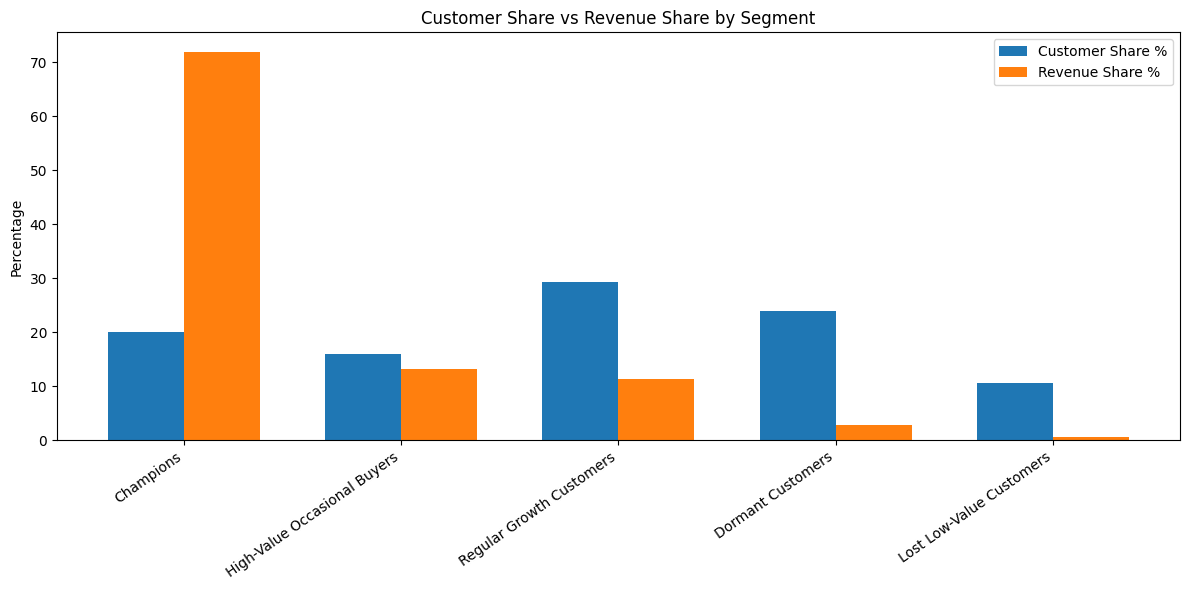

In [193]:
comparison = segment_revenue.reset_index()

x = np.arange(len(comparison))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    comparison["customer_share_pct"],
    width,
    label="Customer Share %"
)

plt.bar(
    x + width / 2,
    comparison["revenue_share_pct"],
    width,
    label="Revenue Share %"
)

plt.xticks(
    x,
    comparison["customer_segment"],
    rotation=35,
    ha="right"
)

plt.ylabel("Percentage")
plt.title(
    "Customer Share vs Revenue Share by Segment"
)

plt.legend()

plt.tight_layout()
plt.show()

In [194]:
segment_actions = {
    "Champions":
        "Protect and strengthen loyalty through exclusive offers, personalized recommendations, and premium engagement.",

    "High-Value Occasional Buyers":
        "Increase purchase frequency through targeted recommendations, bundles, and repeat-purchase incentives.",

    "Regular Growth Customers":
        "Encourage progression toward higher-value behavior through cross-sell, upsell, and loyalty initiatives.",

    "Dormant Customers":
        "Prioritize targeted reactivation using previous purchasing preferences and customer history.",

    "Lost Low-Value Customers":
        "Use selective, low-cost reactivation campaigns and avoid excessive retention investment."
}

action_table = pd.DataFrame(
    segment_actions.items(),
    columns=[
        "customer_segment",
        "recommended_action"
    ]
)

action_table

,customer_segment,recommended_action
0,Champions,Protect and strengthen loyalty through exclusi...
1,High-Value Occasional Buyers,Increase purchase frequency through targeted r...
2,Regular Growth Customers,Encourage progression toward higher-value beha...
3,Dormant Customers,Prioritize targeted reactivation using previou...
4,Lost Low-Value Customers,"Use selective, low-cost reactivation campaigns..."


In [195]:
segment_behavior = (
    customer_data
    .groupby(
        "customer_segment",
        observed=True
    )
    .agg(
        customers=("customer_id", "nunique"),
        median_recency=("recency", "median"),
        median_frequency=("frequency", "median"),
        median_monetary=("monetary", "median"),
        median_avg_order_value=("avg_order_value", "median"),
        median_avg_items_per_order=("avg_items_per_order", "median"),
        median_unique_products=("unique_products", "median"),
        median_active_months=("active_months", "median"),
        median_purchase_interval=(
            "avg_purchase_interval_days",
            "median"
        ),
        median_return_order_rate=(
            "return_order_rate",
            "median"
        ),
        median_return_item_rate=(
            "return_item_rate",
            "median"
        )
    )
    .round(2)
)

segment_behavior

,customers,median_recency,median_frequency,median_monetary,median_avg_order_value,median_avg_items_per_order,median_unique_products,median_active_months,median_purchase_interval,median_return_order_rate,median_return_item_rate
customer_segment,,,,,,,,,,,
Champions,1178,23.00,13.00,"4,976.60",393.61,231.90,172.00,10.00,1.96,0.20,0.01
High-Value Occasional Buyers,945,130.00,2.00,"1,345.21",561.88,360.75,54.00,2.00,1.55,0.00,0.00
Regular Growth Customers,1726,57.00,4.00,"1,004.13",226.69,121.60,56.00,4.00,4.51,0.00,0.00
Dormant Customers,1411,388.00,1.00,306.94,228.96,132.00,19.00,1.00,0.00,0.00,0.00
Lost Low-Value Customers,621,389.00,1.00,121.74,95.93,36.50,6.00,1.00,0.00,0.00,0.00


In [196]:
final_segment_summary = (
    segment_revenue
    .join(
        segment_behavior,
        how="left",
        rsuffix="_behavior"
    )
    .join(
        dominant_rfm,
        how="left"
    )
)

final_segment_summary

,customers,total_revenue,avg_customer_revenue,median_customer_revenue,customer_share_pct,revenue_share_pct,customers_behavior,median_recency,median_frequency,median_monetary,median_avg_order_value,median_avg_items_per_order,median_unique_products,median_active_months,median_purchase_interval,median_return_order_rate,median_return_item_rate,dominant_rfm_segment
customer_segment,,,,,,,,,,,,,,,,,,
Champions,1178,"12,493,975.04","10,606.09","4,976.60",20.03,71.91,1178,23.00,13.00,"4,976.60",393.61,231.90,172.00,10.00,1.96,0.20,0.01,Champions
High-Value Occasional Buyers,945,"2,289,819.68","2,423.09","1,345.21",16.07,13.18,945,130.00,2.00,"1,345.21",561.88,360.75,54.00,2.00,1.55,0.00,0.00,Lost
Regular Growth Customers,1726,"1,981,781.03","1,148.19","1,004.13",29.35,11.41,1726,57.00,4.00,"1,004.13",226.69,121.60,56.00,4.00,4.51,0.00,0.00,Loyal Customers
Dormant Customers,1411,"494,198.73",350.25,306.94,23.99,2.84,1411,388.00,1.00,306.94,228.96,132.00,19.00,1.00,0.00,0.00,0.00,Lost
Lost Low-Value Customers,621,"115,029.78",185.23,121.74,10.56,0.66,621,389.00,1.00,121.74,95.93,36.50,6.00,1.00,0.00,0.00,0.00,Lost


In [197]:
customer_intelligence = customer_data[
    [
        "customer_id",
        "cluster",
        "customer_segment",
        "rfm_segment",

        "recency",
        "frequency",
        "monetary",

        "avg_order_value",
        "avg_items_per_order",
        "unique_products",

        "active_months",
        "customer_lifetime_days",

        "return_order_rate",
        "return_item_rate",

        "value_status"
    ]
].copy()

In [198]:
customer_intelligence["high_value_dormant"] = (
    (customer_intelligence["monetary"] >= high_value_threshold)
    &
    (customer_intelligence["recency"] >= dormant_threshold)
).astype(int)

customer_intelligence["growth_opportunity"] = (
    (customer_intelligence["frequency"] >= frequency_threshold)
    &
    (customer_intelligence["recency"] <= active_recency_threshold)
    &
    (customer_intelligence["monetary"] < high_value_threshold)
).astype(int)

customer_intelligence[
    [
        "customer_id",
        "customer_segment",
        "value_status",
        "high_value_dormant",
        "growth_opportunity"
    ]
].head(10)



,customer_id,customer_segment,value_status,high_value_dormant,growth_opportunity
0,"12,346.00",High-Value Occasional Buyers,High Value - Dormant,0,0
1,"12,347.00",Champions,High Value - Active,0,0
2,"12,348.00",High-Value Occasional Buyers,High Value - Active,0,1
3,"12,349.00",High-Value Occasional Buyers,High Value - Active,0,0
4,"12,350.00",Dormant Customers,Lower Value - Dormant,0,0
5,"12,351.00",Dormant Customers,Lower Value - Dormant,0,0
6,"12,352.00",Regular Growth Customers,High Value - Active,0,0
7,"12,353.00",Dormant Customers,Lower Value - Dormant,0,0
8,"12,354.00",High-Value Occasional Buyers,High Value - Dormant,0,0
9,"12,355.00",High-Value Occasional Buyers,High Value - Dormant,0,0


In [199]:
powerbi_segment = final_segment_summary.copy()

powerbi_segment

,customers,total_revenue,avg_customer_revenue,median_customer_revenue,customer_share_pct,revenue_share_pct,customers_behavior,median_recency,median_frequency,median_monetary,median_avg_order_value,median_avg_items_per_order,median_unique_products,median_active_months,median_purchase_interval,median_return_order_rate,median_return_item_rate,dominant_rfm_segment
customer_segment,,,,,,,,,,,,,,,,,,
Champions,1178,"12,493,975.04","10,606.09","4,976.60",20.03,71.91,1178,23.00,13.00,"4,976.60",393.61,231.90,172.00,10.00,1.96,0.20,0.01,Champions
High-Value Occasional Buyers,945,"2,289,819.68","2,423.09","1,345.21",16.07,13.18,945,130.00,2.00,"1,345.21",561.88,360.75,54.00,2.00,1.55,0.00,0.00,Lost
Regular Growth Customers,1726,"1,981,781.03","1,148.19","1,004.13",29.35,11.41,1726,57.00,4.00,"1,004.13",226.69,121.60,56.00,4.00,4.51,0.00,0.00,Loyal Customers
Dormant Customers,1411,"494,198.73",350.25,306.94,23.99,2.84,1411,388.00,1.00,306.94,228.96,132.00,19.00,1.00,0.00,0.00,0.00,Lost
Lost Low-Value Customers,621,"115,029.78",185.23,121.74,10.56,0.66,621,389.00,1.00,121.74,95.93,36.50,6.00,1.00,0.00,0.00,0.00,Lost


In [200]:
powerbi_opportunities = customer_intelligence[
    [
        "customer_id",
        "customer_segment",
        "rfm_segment",
        "monetary",
        "frequency",
        "recency",
        "avg_order_value",
        "return_order_rate",
        "value_status",
        "high_value_dormant",
        "growth_opportunity"
    ]
].copy()

output_dir = Path("D:/clv/data/processed")

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

customer_intelligence.to_csv(
    output_dir / "customer_intelligence.csv",
    index=False
)

powerbi_segment.to_csv(
    output_dir / "segment_business_summary.csv",
    index=False
)

high_value_dormant.to_csv(
    output_dir / "high_value_dormant_customers.csv",
    index=False
)


growth_candidates.to_csv(
    output_dir / "growth_opportunity_customers.csv",
    index=False
)

powerbi_opportunities.to_csv(
    output_dir / "customer_opportunities.csv",
    index=False
)


In [201]:
print("=" * 60)
print("CUSTOMER INTELLIGENCE OUTPUT VALIDATION")
print("=" * 60)

print(
    "Customers:",
    customer_intelligence["customer_id"].nunique()
)

print(
    "Segments:",
    customer_intelligence["customer_segment"].nunique()
)

print(
    "Total Revenue:",
    f"{customer_intelligence['monetary'].sum():,.2f}"
)

print(
    "High-Value Dormant Customers:",
    customer_intelligence[
        "high_value_dormant"
    ].sum()
)

print(
    "Growth Opportunity Customers:",
    customer_intelligence[
        "growth_opportunity"
    ].sum()
)

print(
    "Output columns:",
    customer_intelligence.shape[1]
)

CUSTOMER INTELLIGENCE OUTPUT VALIDATION
Customers: 5881
Segments: 5
Total Revenue: 17,374,804.27
High-Value Dormant Customers: 65
Growth Opportunity Customers: 1044
Output columns: 17


In [202]:
numeric_cols = customer_intelligence.select_dtypes(
    include="number"
).columns

print("NaN values:")
print(
    customer_intelligence[numeric_cols]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nInfinite values:")
print(
    np.isinf(
        customer_intelligence[numeric_cols]
    ).sum()
    .sort_values(ascending=False)
)

NaN values:
customer_id               0
cluster                   0
recency                   0
frequency                 0
monetary                  0
avg_order_value           0
avg_items_per_order       0
unique_products           0
active_months             0
customer_lifetime_days    0
return_order_rate         0
return_item_rate          0
high_value_dormant        0
growth_opportunity        0
dtype: int64

Infinite values:
customer_id               0
cluster                   0
recency                   0
frequency                 0
monetary                  0
avg_order_value           0
avg_items_per_order       0
unique_products           0
active_months             0
customer_lifetime_days    0
return_order_rate         0
return_item_rate          0
high_value_dormant        0
growth_opportunity        0
dtype: int64
